# Typhoon Impact Modelling

## 0. Setup

In [41]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GroupKFold, GridSearchCV
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, f1_score

from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import Perceptron
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from xgboost import XGBClassifier

from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

## 1. Load & Clean IBTrACS (Book3 Sheet3 + Storm Clusters)

Book3 Sheet3 has a two-row header:
- Row 0: group names (WIND, PRES, R34, ...)
- Row 1: subheaders (min, ave, max, units)

We'll:
- Build proper column names
- Convert Excel errors to NaN
- Convert ISO_TIME (Excel serial) to datetime
- Merge storm cluster labels

In [42]:
book3_path = r"C:\Users\ailene.nunez\Downloads\capstone_project\Book3.xlsx"

# Read the first 2 rows for header
header_raw = pd.read_excel(book3_path, sheet_name="Sheet3", nrows=2, header=None)
h0 = header_raw.iloc[0].tolist()  # row 0
h1 = header_raw.iloc[1].tolist()  # row 1

group_order = ["WIND", "PRES", "R34", "R50", "R64", "POCI", "ROCI", "RMW", "EYE", "GUST"]
colnames = []

for idx in range(len(h0)):
    if idx <= 6:
        # First 7 columns appear to be simple fields:
        # SID, SEASON, NAME, ISO_TIME, NATURE, LAT, LON
        name = h0[idx]
        if isinstance(name, str) and name.strip():
            colnames.append(name.strip())
        else:
            colnames.append(f"col{idx}")
    elif 7 <= idx <= 36:
        # Blocks of 3 columns per group: min / ave / max
        group_idx = (idx - 7) // 3   # 0..9
        group = group_order[group_idx]
        agg = h1[idx]
        if isinstance(agg, str) and agg.strip():
            colnames.append(f"{group}_{agg.strip().lower()}")   
        else:
            colnames.append(f"{group}_col{idx}")
    else:
        # Last 2 columns: STORM_SPEED, STORM_DIR with units in brackets
        base = h0[idx]
        if isinstance(base, str):
            base_clean = base.split("[")[0].strip().upper()
            colnames.append(base_clean)   # STORM_SPEED, STORM_DIR
        else:
            colnames.append(f"col{idx}")

len(colnames), colnames[:12]

(39,
 ['SID',
  'SEASON',
  'NAME',
  'ISO_TIME',
  'NATURE',
  'LAT',
  'LON',
  'WIND_min',
  'WIND_ave',
  'WIND_max',
  'PRES_min',
  'PRES_ave'])

In [43]:
ib_agg = pd.read_excel(
    book3_path,
    sheet_name="Sheet3",
    header=None,
    skiprows=2,
    names=colnames
)

In [44]:
# Clean Excel errors like "#DIV/0!"
ib_agg = ib_agg.replace("#DIV/0!", np.nan)

# Identify numeric vs non-numeric
non_numeric_base = ["SID", "SEASON", "NAME", "ISO_TIME", "NATURE"]
numeric_cols = [c for c in ib_agg.columns if c not in non_numeric_base]

for c in numeric_cols:
    ib_agg[c] = pd.to_numeric(ib_agg[c], errors="coerce")

# Convert ISO_TIME (Excel serial) to datetime
excel_origin = pd.Timestamp("1899-12-30")
ib_agg["ISO_TIME_dt"] = excel_origin + pd.to_timedelta(ib_agg["ISO_TIME"], unit="D")

# Clean storm name to UPPER, for later joining
ib_agg["NAME"] = ib_agg["NAME"].astype(str).str.upper()

ib_agg.head()


,SID,SEASON,NAME,ISO_TIME,NATURE,LAT,LON,WIND_min,WIND_ave,WIND_max,PRES_min,PRES_ave,PRES_max,R34_min,R34_ave,R34_max,R50_min,R50_ave,R50_max,R64_min,R64_ave,R64_max,POCI_min,POCI_ave,POCI_max,ROCI_min,ROCI_ave,ROCI_max,RMW_min,RMW_ave,RMW_max,EYE_min,EYE_ave,EYE_max,GUST_min,GUST_ave,GUST_max,STORM_SPEED,STORM_DIR,ISO_TIME_dt
0,2000125N06136,2000,DAMREY,36649.750,TS,6.2,135.7,25,25.0,25,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,12,345,2000-05-03 18:00:00
1,2000125N06136,2000,DAMREY,36649.875,TS,6.8,135.5,25,25.0,25,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,11,345,2000-05-03 21:00:00
2,2000125N06136,2000,DAMREY,36650.000,TS,7.3,135.4,25,25.0,25,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,10,350,2000-05-04 00:00:00
3,2000125N06136,2000,DAMREY,36650.125,TS,7.7,135.3,25,25.0,25,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,8,355,2000-05-04 03:00:00
4,2000125N06136,2000,DAMREY,36650.250,TS,8.1,135.3,25,25.0,25,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,6,0,2000-05-04 06:00:00


In [45]:
ib_agg = ib_agg.sort_values(["SID", "ISO_TIME_dt"])

idx_max_wind = (
    ib_agg.groupby("SID")["WIND_max"]
         .idxmax()
)

storm_event_times = (
    ib_agg.loc[idx_max_wind, ["SID", "ISO_TIME_dt"]]
         .rename(columns={"ISO_TIME_dt": "event_time_utc"})
         .reset_index(drop=True)
)

storm_event_times

,SID,event_time_utc
0,0,1899-12-30 00:00:00
1,2000125N06136,2000-05-09 18:00:00
2,2000138N16119,2000-05-19 18:00:00
3,2000141N18116,2000-05-21 00:00:00
4,2000150N11117,2000-05-31 12:00:00
...,...,...
788,2025305N10138,2025-11-06 00:00:00
789,2025308N10143,2025-11-09 06:00:00
790,2025329N10124,2025-11-27 00:00:00
791,2025330N05099,2025-11-25 18:00:00


In [46]:
# Month (1–12) from UTC time
storm_event_times["event_time_utc"] = pd.to_datetime(storm_event_times["event_time_utc"])
storm_event_times["month"] = storm_event_times["event_time_utc"].dt.month

def phil_season(month):
    # basic DJF/MAM/JJA/SON;
    if month in [3, 4, 5]:
        return "MAM"   # hot / early rains
    elif month in [6, 7, 8]:
        return "JJA"   # SW monsoon peak
    elif month in [9, 10, 11]:
        return "SON"   # late monsoon, many strong typhoons
    else:  # 12,1,2
        return "DJF"   # NE monsoon, fewer storms

storm_event_times["season"] = storm_event_times["month"].apply(phil_season)

storm_event_times

,SID,event_time_utc,month,season
0,0,1899-12-30 00:00:00,12,DJF
1,2000125N06136,2000-05-09 18:00:00,5,MAM
2,2000138N16119,2000-05-19 18:00:00,5,MAM
3,2000141N18116,2000-05-21 00:00:00,5,MAM
4,2000150N11117,2000-05-31 12:00:00,5,MAM
...,...,...,...,...
788,2025305N10138,2025-11-06 00:00:00,11,SON
789,2025308N10143,2025-11-09 06:00:00,11,SON
790,2025329N10124,2025-11-27 00:00:00,11,SON
791,2025330N05099,2025-11-25 18:00:00,11,SON


In [47]:
ib_agg = ib_agg.merge(storm_event_times[["SID", "season"]], on="SID", how="left") 

In [48]:
clusters = pd.read_csv(r"C:\Users\ailene.nunez\Downloads\capstone_project\ibtracs.WP.trackonly20xx_storm_clusters.csv")

# This file typically has ID (SID) and CLUSTER
clusters = clusters.rename(columns={"ID": "SID", "CLUSTER": "storm_cluster"})

ib_agg = ib_agg.merge(
    clusters[["SID", "storm_cluster"]],
    on="SID",
    how="left"
)

ib_agg[["SID", "SEASON", "NAME", "storm_cluster"]].drop_duplicates().head()

,SID,SEASON,NAME,storm_cluster
0,0,0,0,NaN
9,2000125N06136,2000,DAMREY,0.0
114,2000138N16119,2000,LONGWANG,2.0
171,2000141N18116,2000,UNNAMED,7.0
190,2000150N11117,2000,UNNAMED,2.0


In [49]:
ib_core = ib_agg[[
'SID', 'SEASON', 'ISO_TIME_dt', 'NAME', 'NATURE', 'WIND_min', 'WIND_ave', 'WIND_max', 'PRES_min', 'PRES_ave', 'PRES_max', 'R34_min', 'R34_ave', 'R34_max', 'R50_min', 'R50_ave',
       'R50_max', 'R64_min', 'R64_ave', 'R64_max', 'POCI_min', 'POCI_ave', 'POCI_max', 'ROCI_min', 'ROCI_ave', 'ROCI_max', 'RMW_min', 'RMW_ave', 'RMW_max', 'EYE_min', 'EYE_ave', 'EYE_max',
       'GUST_min', 'GUST_ave', 'GUST_max', 'STORM_SPEED', 'STORM_DIR', 'season', 'storm_cluster'
]].copy()

ib_core.head()


,SID,SEASON,ISO_TIME_dt,NAME,NATURE,WIND_min,WIND_ave,WIND_max,PRES_min,PRES_ave,PRES_max,R34_min,R34_ave,R34_max,R50_min,R50_ave,R50_max,R64_min,R64_ave,R64_max,POCI_min,POCI_ave,POCI_max,ROCI_min,ROCI_ave,ROCI_max,RMW_min,RMW_ave,RMW_max,EYE_min,EYE_ave,EYE_max,GUST_min,GUST_ave,GUST_max,STORM_SPEED,STORM_DIR,season,storm_cluster
0,0,0,1899-12-30,0,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,0,DJF,NaN
1,0,0,1899-12-30,0,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,0,DJF,NaN
2,0,0,1899-12-30,0,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,0,DJF,NaN
3,0,0,1899-12-30,0,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,0,DJF,NaN
4,0,0,1899-12-30,0,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN,0,0,0,DJF,NaN


Aggregate IBTrACS from track points -> **storm-level** features

Simpler v1 assumption: hazard features are the same for all Metro Manila cities
for a given storm. (Later you can upgrade to city-specific hazard using distance to track.)

In [50]:
ib_core = ib_core.sort_values(["SID", "ISO_TIME_dt"])

# 1) Index of maximum WIND_max per storm
idx_peak = (
    ib_core
    .groupby("SID")["WIND_max"]
    .idxmax()
)

# 2) NATURE at peak intensity
nature_peak = (
    ib_core.loc[idx_peak, ["SID", "NATURE"]]
           .rename(columns={"NATURE": "NATURE_peak"})
)

# 2) Aggregate storm-level numeric features

agg_dict = {
    "WIND_max": "max",
    "WIND_ave": "mean",
    "PRES_min": "min",
    "R34_max": "max",
    "R50_max": "max",
    "R64_max": "max",
    "POCI_ave": "mean",
    "ROCI_ave": "mean",
    "RMW_ave": "mean",
    "GUST_max": "max",
    "STORM_SPEED": "mean",
    "STORM_DIR": "mean",
    "storm_cluster": "first",
    "season": "first"
}

ib_event = (
    ib_core
    .groupby(["SID", "SEASON", "NAME"], as_index=False)
    .agg(agg_dict)
    .merge(nature_peak, on="SID", how="left")
)

ib_event.head()

,SID,SEASON,NAME,WIND_max,WIND_ave,PRES_min,R34_max,R50_max,R64_max,POCI_ave,ROCI_ave,RMW_ave,GUST_max,STORM_SPEED,STORM_DIR,storm_cluster,season,NATURE_peak
0,0,0,0,0,NaN,0,0,0,0,NaN,NaN,NaN,0,0.000000,0.000000,NaN,DJF,0
1,2000125N06136,2000,DAMREY,155,54.798122,0,500,150,0,NaN,NaN,NaN,0,10.247619,119.761905,0.0,MAM,TS
2,2000138N16119,2000,LONGWANG,45,29.418966,990,150,0,0,NaN,NaN,NaN,0,21.771930,64.912281,2.0,MAM,TS
3,2000141N18116,2000,UNNAMED,30,28.543860,1002,0,0,0,NaN,NaN,NaN,0,12.736842,73.157895,7.0,MAM,TS
4,2000150N11117,2000,UNNAMED,30,23.661290,0,0,0,0,NaN,NaN,NaN,0,9.967742,310.483871,2.0,MAM,TS


## 2. Load & Clean Rapid Intensification Data

In [51]:
rap_int = pd.read_csv(r"C:\Users\ailene.nunez\Downloads\capstone_project\rapid_intensification.csv")

rap_int.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,SID,RI_true,NaiveBayes_pred,SVM_pred,ANN_pred
0,-1.420805,-0.166398,-0.719625,0.449440,0.301554,0.271589,0.251894,-0.889265,-0.966452,-0.956348,-0.609011,-0.626457,-0.614561,-0.424084,-0.426084,-0.420932,0.618919,0.741987,0.389127,-0.19946,-0.156611,-1.427855,-0.174750,-0.868878,0.541526,0.297572,0.282039,0.269306,-0.899256,-0.977197,-0.965840,-0.611361,-0.628788,-0.616692,-0.425736,-0.42734,-0.422126,0.616034,0.791751,0.255678,-0.197027,-0.157603,-1.424874,-0.178396,-1.158208,0.678472,0.304413,0.275543,0.262000,-0.905247,-0.983680,-0.971702,-0.612776,-0.630180,-0.617692,-0.427002,-0.428466,-0.42316,0.610376,0.789679,0.256421,-0.199936,-0.157554,-1.421898,-0.177453,-1.155240,0.856568,0.310272,0.280407,0.253462,-0.908491,-0.986947,-0.974390,-0.612969,-0.630483,-0.617851,-0.427602,-0.429202,-0.423748,0.609194,0.790752,0.260913,-0.196699,-0.157497,-1.419124,-0.171969,-1.153055,0.904773,0.302142,0.271532,0.243811,-0.911728,-0.990688,-0.977665,-0.613266,-0.631005,-0.618334,-0.428006,-0.429639,-0.424333,0.614652,0.795905,0.274307,-0.201181,-0.155408,-1.416666,-0.171887,-1.009439,0.793201,0.292903,0.272413,0.260384,-0.248207,0.224869,0.755746,-0.614296,-0.631919,-0.619363,-0.427508,-0.42934,-0.424348,0.622540,0.802792,0.288378,-0.197035,-0.157871,-1.405046,-0.181956,-0.869868,0.722564,0.295455,0.267283,0.249110,-0.164893,0.300460,0.753768,-0.615629,-0.632969,-0.620323,-0.427040,-0.428926,-0.423834,0.633939,0.708334,0.306458,-0.200808,-0.15592,-1.403067,-0.187514,-1.000588,0.568947,0.296591,0.256792,0.236505,-0.380897,0.191557,0.753569,-0.615727,-0.633334,-0.620431,-0.428103,-0.429887,-0.424590,0.645071,0.617763,0.327146,-0.196471,-0.157308,2021046N06142,1,1,1,1
1,-0.522647,-0.758210,-0.719625,0.619397,0.267013,0.256166,0.263487,-0.889265,-0.966452,-0.956348,-0.609011,-0.626457,-0.614561,-0.424084,-0.426084,-0.420932,-1.621229,-1.378550,-1.075217,-0.19946,-0.156611,-0.521069,-0.764545,-0.721211,0.626275,0.273514,0.269948,0.269306,-0.899256,-0.977197,-0.965840,-0.611361,-0.628788,-0.616692,-0.425736,-0.42734,-0.422126,-1.634851,-1.387607,-1.082169,-0.197027,-0.157603,-0.529444,-0.770830,-0.577592,0.594115,0.279517,0.263024,0.274558,-0.905247,-0.983680,-0.971702,-0.612776,-0.630180,-0.617692,-0.427002,-0.428466,-0.42316,-1.644104,-1.393028,-1.087603,-0.199936,-0.157554,-0.527974,-0.782049,-0.296622,0.604617,0.284665,0.280407,0.279312,-0.908491,-0.986947,-0.974390,-0.612969,-0.630483,-0.617851,-0.427602,-0.429202,-0.423748,-1.641365,-1.390853,-1.087043,-0.196699,-0.157497,-0.526670,-0.798073,-0.163850,0.653265,0.302142,0.280330,0.283544,-0.911728,-0.990688,-0.977665,-0.613266,-0.631005,-0.618334,-0.428006,-0.429639,-0.424333,-1.626896,-1.380621,-1.084226,-0.201181,-0.155408,-0.525555,-0.813949,-0.453109,0.751452,0.319702,0.302095,0.287470,-0.911589,-0.991632,-0.979105,-0.614296,-0.631919,-0.619363,-0.427508,-0.42934,-0.424348,-1.606513,-1.365727,-1.078071,-0.197035,-0.157871,-0.524578,-0.810092,-0.596772,0.972322,0.322598,0.277534,0.235387,-0.914067,-0.992924,-0.979798,-0.615629,-0.632969,-0.620323,-0.427040,-0.428926,-0.423834,-1.577819,-1.345628,-1.065516,-0.200808,-0.15592,-0.505211,-0.811081,-0.332056,1.025365,0.323911,0.278807,0.236505,-0.913673,-0.992107,-0.978777,-0.615727,-0.633334,-0.620431,-0.428103,-0.429887,-0.424590,-1.545563,-1.322886,-1.052201,-0.196471,-0.157308,2004327N16125,0,1,1,1
2,-0.482280,0.881811,-0.569753,0.916823,0.174901,0.164404,0.147554,-0.226459,0.592331,0

In [52]:
# Recreate time index
rap_int['RI_window_index'] = rap_int.groupby('SID').cumcount()

# Sort for sequential analysis
ri_sorted = rap_int.sort_values(by=['SID', 'RI_window_index'])

# Detect transitions into RI events
ri_sorted['RI_prev'] = ri_sorted.groupby('SID')['RI_true'].shift(1, fill_value=0)
ri_sorted['RI_new_episode'] = ((ri_sorted['RI_true'] == 1) & (ri_sorted['RI_prev'] == 0)).astype(int)

# Count new RI episodes per storm
ri_episode_counts = ri_sorted.groupby('SID')['RI_new_episode'].sum().reset_index()
ri_episode_counts.columns = ['SID', 'RI_episode_count']

# Create RI summary
ri_summary = rap_int.groupby('SID').agg(
    has_RI=('RI_true', 'max'),
    predicted_RI_NB=('NaiveBayes_pred', 'max'),
    predicted_RI_SVM=('SVM_pred', 'max'),
    predicted_RI_ANN=('ANN_pred', 'max'),
    RI_event_count=('RI_true', 'sum'),
    total_windows=('RI_true', 'count')
).reset_index()

# Earliest RI window per storm
ri_events = rap_int[rap_int['RI_true'] == 1]
earliest_ri = ri_events.groupby('SID')['RI_window_index'].min().reset_index()
earliest_ri.columns = ['SID', 'first_RI_window_index']

# Merge all into one summary
ri_summary_full = ri_summary.merge(earliest_ri, on='SID', how='left')
ri_summary_full = ri_summary_full.merge(ri_episode_counts, on='SID', how='left')

In [53]:
ri_summary_full

,SID,has_RI,predicted_RI_NB,predicted_RI_SVM,predicted_RI_ANN,RI_event_count,total_windows,first_RI_window_index,RI_episode_count
0,0,0,1,0,0,0,1,NaN,0
1,2000125N06136,1,1,1,1,12,26,4.0,6
2,2000138N16119,1,0,1,1,1,8,2.0,1
3,2000150N11117,0,1,1,1,0,5,NaN,0
4,2000169N17114,0,1,0,0,0,3,NaN,0
...,...,...,...,...,...,...,...,...,...
767,2025305N10138,0,1,1,1,0,8,NaN,0
768,2025308N10143,1,1,1,1,4,9,3.0,2
769,2025329N10124,0,1,1,1,0,9,NaN,0
770,2025330N05099,0,1,0,0,0,1,NaN,0


In [54]:
ri_data = ri_summary_full[["SID", "has_RI", "first_RI_window_index"]]
ri_data["has_RI"] = ri_data["has_RI"].astype(bool)
ri_data.head()

C:\Users\ailene.nunez\AppData\Local\Temp\ipykernel_24116\572628472.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ri_data["has_RI"] = ri_data["has_RI"].astype(bool)


,SID,has_RI,first_RI_window_index
0,0,False,NaN
1,2000125N06136,True,4.0
2,2000138N16119,True,2.0
3,2000150N11117,False,NaN
4,2000169N17114,False,NaN


## 3. Load & Clean Impact Data

`impact_data_cleaned.csv` should be per (city, typhoon, year) with impact band.
We'll:
- standardize a city key `city_std`
- map PAGASA typhoon names -> international names
- prepare a target column.

In [55]:
impact = pd.read_csv(r"C:\Users\ailene.nunez\Downloads\capstone_project\impact_data_with_exposure_disruption_index.csv")

impact.head()

,typhoon,city,combined_effect,combined_with,year,affected_barangays,affected_families,affected_persons,evacuated_families,evacuated_persons,class_suspension,work_suspension,flooded,state_of_calamity,power_interruption,injured,dead,missing,number_of_barangays,population,population_orig,population_is_interpolated,number_of_families,number_of_families_orig,number_of_families_is_interpolated,affected_brgys_pct,affected_fams_pct,affected_pop_pct,evacuated_fams_pct,evacuated_pop_pct,affected_brgys_pct_cap,affected_fams_pct_cap,affected_pop_pct_cap,evacuated_fams_pct_cap,evacuated_pop_pct_cap,affected_brgys_pct_norm,affected_fams_pct_norm,affected_pop_pct_norm,evacuated_fams_pct_norm,evacuated_pop_pct_norm,exposure_index_0_1,exposure_index_0_100,class_suspension_bin,work_suspension_bin,flooded_bin,state_of_calamity_bin,power_interruption_bin,disrupt_bool_component,injured_per_100k,dead_per_100k,missing_per_100k,injured_per_100k_norm,dead_per_100k_norm,missing_per_100k_norm,disrupt_casualty_component,disruption_index_0_1,disruption_index_0_100,impact_severity_0_1,impact_severity_0_100,impact_severity_3band,exposure_severity_3band,disruption_severity_3band
0,Rolly,Caloocan,False,NaN,2020,1,1,5,0,0,False,False,False,0.0,0.0,0,0,0,188,1661584,1661584.0,0,404252,404252.0,0,0.531915,0.000247,0.000301,0.0,0.0,0.531915,0.000247,0.000301,0.0,0.0,0.005319,0.000004,0.000005,0.0,0.0,0.001066,0.1,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000639,0.063940,Low,Low,Low
1,Rolly,Las Piñas,False,NaN,2020,4,37,119,0,0,False,False,False,0.0,0.0,0,0,0,20,606293,606293.0,0,156899,156899.0,0,20.000000,0.023582,0.019627,0.0,0.0,20.000000,0.023582,0.019627,0.0,0.0,0.200000,0.000391,0.000334,0.0,0.0,0.040145,4.0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.024087,2.408700,Low,Low,Low
2,Rolly,Makati,False,NaN,2020,0,0,0,0,0,False,False,False,0.0,0.0,0,0,0,33,629616,629616.0,0,186381,186381.0,0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,Low,Low,Low
3,Rolly,Malabon,False,NaN,2020,6,105,447,0,0,False,False,False,0.0,0.0,0,0,0,21,380522,380522.0,0,94241,94241.0,0,28.571429,0.111416,0.117470,0.0,0.0,28.571429,0.111416,0.117470,0.0,0.0,0.285714,0.001846,0.002001,0.0,0.0,0.057912,5.8,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.034747,3.474734,Low,Medium,Low
4,Rolly,Mandaluyong,False,NaN,2020,0,0,0,0,0,False,False,False,0.0,0.0,0,0,0,27,425758,425758.0,0,116954,116954.0,0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,Low,Low,Low


In [56]:
# Standardize city name
impact["city_std"] = impact["city"].astype(str).str.strip()
impact["typhoon"] = impact["typhoon"].astype(str).str.strip()

# PH (PAGASA) -> International name mapping
pagasa_to_intl = {
    "Rolly":    "GONI",
    "Ulysses":  "VAMCO",
    "Jolina":   "CONSON",
    "Karding":  "NORU",
    "Paeng":    "NALGAE",
    "Aghon":    "EWINIAR",
    "Carina":   "GAEMI",
    "Enteng":   "YAGI",
    "Jenny":    "KOINU",
    "Kristine": "TRAMI",
    "Kiko":     "PEIPAH",
    "Uwan":     "FUNG-WONG",
}

impact["typhoon_intl"] = impact["typhoon"].map(pagasa_to_intl).str.lower()

impact[["typhoon", "year", "typhoon_intl"]].drop_duplicates().sort_values(["year","typhoon"])


,typhoon,year,typhoon_intl
0,Rolly,2020,goni
17,Ulysses,2020,vamco
34,Jolina,2021,conson
51,Karding,2022,noru
68,Paeng,2022,nalgae
85,Jenny,2023,koinu
102,Aghon,2024,ewiniar
119,Carina,2024,gaemi
136,Enteng,2024,yagi
153,Kristine,2024,trami


In [57]:
mask_kiko = impact["typhoon"] == "Kiko"
impact.loc[mask_kiko, "combined_effect"] = True
impact.loc[mask_kiko, "combined_with"] = "SW Moonsoon"

In [58]:
TARGET_COL = "impact_severity_3band"     

if TARGET_COL not in impact.columns:
    print("WARNING: TARGET_COL not found in impact; please update TARGET_COL to the correct column name.")

impact[TARGET_COL].value_counts(dropna=False)


impact_severity_3band
Medium    95
Low       61
High      48
Name: count, dtype: int64

## 4. Load & Clean Flood Hazard (5-year) Data

`city_hazard_features_5yr.csv` is per city (ADM3) with hazard shares.
We'll:
- map ADM3_EN to `city_std`
- keep the flood share columns we care about.

In [59]:
hz5 = pd.read_csv(r"C:\Users\ailene.nunez\Downloads\capstone_project\city_hazard_features_5yr.csv")
hz5.head()

,ADM3_EN,n_barangays,total_city_area_sqkm,city_area_5yr_low,city_area_5yr_med,city_area_5yr_high,city_area_5yr_any,city_pct_area_5yr_low,city_pct_area_5yr_med,city_pct_area_5yr_high,city_pct_area_5yr_any,hazard_raw_5yr,hazard_score_5yr,severe_share_5yr
0,Caloocan City,1647,477.4571,42.393893,29.560837,13.109865,85.064595,0.088791,0.061913,0.027458,0.178162,0.178162,0.109889,0.154117
1,City of Las Piñas,20,32.7536,4.398689,3.669699,0.846478,8.914866,0.134296,0.112040,0.025844,0.272180,0.272180,0.248607,0.094951
2,City of Makati,91,71.6076,13.898978,5.245882,1.915064,21.059924,0.194099,0.073259,0.026744,0.294102,0.294102,0.280952,0.090934
3,City of Malabon,27,18.2385,4.582558,3.599331,0.643137,8.825026,0.251257,0.197348,0.035263,0.483868,0.483868,0.560942,0.072877
4,City of Mandaluyong,62,20.9555,2.669249,1.758720,0.495305,4.923274,0.127377,0.083926,0.023636,0.234939,0.234939,0.193661,0.100605


In [60]:
# Map hazard city labels to city_std (aligned with impact.city)
city_map_hz_to_std = {
    "Caloocan City":       "Caloocan",
    "City of Las Piñas":   "Las Piñas",
    "City of Makati":      "Makati",
    "City of Malabon":     "Malabon",
    "City of Mandaluyong": "Mandaluyong",
    "City of Manila":      "Manila",
    "City of Marikina":    "Marikina",
    "City of Muntinlupa":  "Muntinlupa",
    "City of Navotas":     "Navotas",
    "City of Parañaque":   "Parañaque",
    "City of Pasig":       "Pasig",
    "City of San Juan":    "San Juan",
    "City of Valenzuela":  "Valenzuela",
    "Pasay City":          "Pasay",
    "Pateros":             "Pateros",
    "Quezon City":         "Quezon City",
    "Taguig City":         "Taguig",
}

hz5["city_std"] = hz5["ADM3_EN"].map(city_map_hz_to_std)

flood_cols = [
    "city_pct_area_5yr_low",
    "city_pct_area_5yr_med",
    "city_pct_area_5yr_high"
]

for c in flood_cols:
    if c not in hz5.columns:
        print(f"WARNING: Flood column {c} not found in hz5; adjust flood_cols.")
        
hz5[["city_std"] + [c for c in flood_cols if c in hz5.columns]].head()

,city_std,city_pct_area_5yr_low,city_pct_area_5yr_med,city_pct_area_5yr_high
0,Caloocan,0.088791,0.061913,0.027458
1,Las Piñas,0.134296,0.112040,0.025844
2,Makati,0.194099,0.073259,0.026744
3,Malabon,0.251257,0.197348,0.035263
4,Mandaluyong,0.127377,0.083926,0.023636


## 5. Load & Build Poverty Features

From `poverty_data_type_urls.xlsx`, we use:
- Sheet `poor_households` → city vs poor_households_2018
- Sheet `poverty_estimate_2018` → city vs poverty_rate_2018

Then we merge these into one `poverty_features` table keyed on `city_std`.

In [61]:
poverty_xls = pd.ExcelFile(r"C:\Users\ailene.nunez\Downloads\capstone_project\poverty_data_type_urls.xlsx")

# --- poor households sheet ---
poor_raw = poverty_xls.parse("poor_households")

poor = poor_raw.rename(
    columns={
        "Unnamed: 0": "city_raw",
        "Unnamed: 1": "poor_households_2018"
    }
)

mask_city = (
    poor["city_raw"].notna()
    & (~poor["city_raw"].astype(str).str.contains("Average of", na=False))
    & (~poor["city_raw"].isin(["Row Labels", "Grand Total"]))
)

poor = poor.loc[mask_city, ["city_raw", "poor_households_2018"]].copy()
poor["poor_households_2018"] = pd.to_numeric(poor["poor_households_2018"], errors="coerce")
poor["city_std"] = poor["city_raw"].astype(str).str.strip()

poor.head()

,city_raw,poor_households_2018,city_std
3,Caloocan,74633,Caloocan
4,Las Piñas,4526,Las Piñas
5,Makati,2288,Makati
6,Malabon,5781,Malabon
7,Mandaluyong,2273,Mandaluyong


In [62]:
# --- poverty rate sheet ---
pov_raw = poverty_xls.parse("poverty_estimate_2018")

pov = pov_raw.rename(
    columns={
        "Average of PSA 2018 First Semester Poverty Statistics Value": "city_raw",
        "Column Labels": "poverty_rate_2018"
    }
)

mask_city2 = (
    pov["city_raw"].notna()
    & (~pov["city_raw"].isin(["Row Labels", "Grand Total"]))
)

pov = pov.loc[mask_city2, ["city_raw", "poverty_rate_2018"]].copy()
pov["poverty_rate_2018"] = pd.to_numeric(pov["poverty_rate_2018"], errors="coerce")
pov["city_std"] = pov["city_raw"].astype(str).str.strip()

pov.head()

,city_raw,poverty_rate_2018,city_std
1,Caloocan,7.8,Caloocan
2,Las Piñas,4.0,Las Piñas
3,Makati,0.9,Makati
4,Malabon,9.0,Malabon
5,Mandaluyong,6.9,Mandaluyong


In [63]:
poverty_features = (
    poor[["city_std", "poor_households_2018"]]
    .merge(
        pov[["city_std", "poverty_rate_2018"]],
        on="city_std",
        how="outer"
    )
)

poverty_features.head()

,city_std,poor_households_2018,poverty_rate_2018
0,Caloocan,74633,7.8
1,Las Piñas,4526,4.0
2,Makati,2288,0.9
3,Malabon,5781,9.0
4,Mandaluyong,2273,6.9


## 6. Merge Everything into a Modeling Table

Keys:
- Impact ↔ IBTrACS: `(year, typhoon_intl == NAME, city_std)`  
  → For now we use storm-level hazard (same per NCR city), so we join on `(year, typhoon_intl == NAME)` only.
- Impact ↔ Rapid Intensification: `SID`
- Impact ↔ Flood hazard: `city_std`
- Impact ↔ Poverty: `city_std`

In [64]:
# First, align IBTrACS storm name & year
ib_event["NAME"] = ib_event["NAME"].astype(str).str.lower()
ib_event["NAME"] = ib_event["NAME"].str.strip()
ib_event = ib_event.rename(columns={"SEASON": "year"})

impact = impact[["city_std", "year", "typhoon", "typhoon_intl", "combined_effect", "combined_with", "impact_severity_3band"]]

# Merge Impact + IBTrACS hazard
df = impact.merge(
    ib_event,
    left_on=["year", "typhoon_intl"],
    right_on=["year", "NAME"],
    how="left",
    suffixes=("", "_ib")
)

print("After merging IBTrACS:", df.shape)
df

After merging IBTrACS: (204, 24)


,city_std,year,typhoon,typhoon_intl,combined_effect,combined_with,impact_severity_3band,SID,NAME,WIND_max,WIND_ave,PRES_min,R34_max,R50_max,R64_max,POCI_ave,ROCI_ave,RMW_ave,GUST_max,STORM_SPEED,STORM_DIR,storm_cluster,season,NATURE_peak
0,Caloocan,2020,Rolly,goni,False,NaN,Low,2020299N11144,goni,170,52.495189,884,210,90,50,1007.952941,151.023529,26.567010,0,8.381443,272.319588,4.0,SON,TS
1,Las Piñas,2020,Rolly,goni,False,NaN,Low,2020299N11144,goni,170,52.495189,884,210,90,50,1007.952941,151.023529,26.567010,0,8.381443,272.319588,4.0,SON,TS
2,Makati,2020,Rolly,goni,False,NaN,Low,2020299N11144,goni,170,52.495189,884,210,90,50,1007.952941,151.023529,26.567010,0,8.381443,272.319588,4.0,SON,TS
3,Malabon,2020,Rolly,goni,False,NaN,Low,2020299N11144,goni,170,52.495189,884,210,90,50,1007.952941,151.023529,26.567010,0,8.381443,272.319588,4.0,SON,TS
4,Mandaluyong,2020,Rolly,goni,False,NaN,Low,2020299N11144,goni,170,52.495189,884,210,90,50,1007.952941,151.023529,26.567010,0,8.381443,272.319588,4.0,SON,TS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199,Pateros,2025,Uwan,fung-wong,False,NaN,Medium,2025308N10143,fung-wong,115,57.453333,943,325,0,0,1006.466667,329.680000,60.373333,0,12.386667,207.333333,6.0,SON,NR
200,Quezon City,2025,Uwan,fung-wong,False,NaN,High,2025308N10143,fung-wong,115,57.453333,943,325,0,0,1006.466667,329.680000,60.373333,0,12.386667,207.333333,6.0,SON,NR
201,San Juan,2025,Uwan,fung-wong,False,NaN,Medium,2025308N10143,fung-wong,115,57.453333,943,325,0,0,1006.466667,329.680000,60.373333,0,12.386667,207.333333,6.0,SON,NR
202,Taguig,2025,Uwan,fung-wong,False,NaN,Medium,2025308N10143,fung-wong,115,57.453333,943,325,0,0,1006.466667,329.680000,60.373333,0,12.386667,207.333333,6.0,SON,NR


In [65]:
# Add ri data

df = df.merge(ri_data, on="SID", how="left")

print("After merging RI data:", df.shape)
df

After merging RI data: (204, 26)


,city_std,year,typhoon,typhoon_intl,combined_effect,combined_with,impact_severity_3band,SID,NAME,WIND_max,WIND_ave,PRES_min,R34_max,R50_max,R64_max,POCI_ave,ROCI_ave,RMW_ave,GUST_max,STORM_SPEED,STORM_DIR,storm_cluster,season,NATURE_peak,has_RI,first_RI_window_index
0,Caloocan,2020,Rolly,goni,False,NaN,Low,2020299N11144,goni,170,52.495189,884,210,90,50,1007.952941,151.023529,26.567010,0,8.381443,272.319588,4.0,SON,TS,True,3.0
1,Las Piñas,2020,Rolly,goni,False,NaN,Low,2020299N11144,goni,170,52.495189,884,210,90,50,1007.952941,151.023529,26.567010,0,8.381443,272.319588,4.0,SON,TS,True,3.0
2,Makati,2020,Rolly,goni,False,NaN,Low,2020299N11144,goni,170,52.495189,884,210,90,50,1007.952941,151.023529,26.567010,0,8.381443,272.319588,4.0,SON,TS,True,3.0
3,Malabon,2020,Rolly,goni,False,NaN,Low,2020299N11144,goni,170,52.495189,884,210,90,50,1007.952941,151.023529,26.567010,0,8.381443,272.319588,4.0,SON,TS,True,3.0
4,Mandaluyong,2020,Rolly,goni,False,NaN,Low,2020299N11144,goni,170,52.495189,884,210,90,50,1007.952941,151.023529,26.567010,0,8.381443,272.319588,4.0,SON,TS,True,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199,Pateros,2025,Uwan,fung-wong,False,NaN,Medium,2025308N10143,fung-wong,115,57.453333,943,325,0,0,1006.466667,329.680000,60.373333,0,12.386667,207.333333,6.0,SON,NR,True,3.0
200,Quezon City,2025,Uwan,fung-wong,False,NaN,High,2025308N10143,fung-wong,115,57.453333,943,325,0,0,1006.466667,329.680000,60.373333,0,12.386667,207.333333,6.0,SON,NR,True,3.0
201,San Juan,2025,Uwan,fung-wong,False,NaN,Medium,2025308N10143,fung-wong,115,57.453333,943,325,0,0,1006.466667,329.680000,60.373333,0,12.386667,207.333333,6.0,SON,NR,True,3.0
202,Taguig,2025,Uwan,fung-wong,False,NaN,Medium,2025308N10143,fung-wong,115,57.453333,943,325,0,0,1006.466667,329.680000,60.373333,0,12.386667,207.333333,6.0,SON,NR,True,3.0


In [66]:
# Add flood hazard (5yr) by city
df = df.merge(
    hz5[["city_std"] + [c for c in flood_cols if c in hz5.columns]],
    on="city_std",
    how="left"
)

print("After adding flood hazard:", df.shape)

After adding flood hazard: (204, 29)


In [67]:
# Add poverty features
df = df.merge(
    poverty_features,
    on="city_std",
    how="left"
)

print("After adding poverty features:", df.shape)

df.head()

After adding poverty features: (204, 31)


,city_std,year,typhoon,typhoon_intl,combined_effect,combined_with,impact_severity_3band,SID,NAME,WIND_max,WIND_ave,PRES_min,R34_max,R50_max,R64_max,POCI_ave,ROCI_ave,RMW_ave,GUST_max,STORM_SPEED,STORM_DIR,storm_cluster,season,NATURE_peak,has_RI,first_RI_window_index,city_pct_area_5yr_low,city_pct_area_5yr_med,city_pct_area_5yr_high,poor_households_2018,poverty_rate_2018
0,Caloocan,2020,Rolly,goni,False,NaN,Low,2020299N11144,goni,170,52.495189,884,210,90,50,1007.952941,151.023529,26.56701,0,8.381443,272.319588,4.0,SON,TS,True,3.0,0.088791,0.061913,0.027458,74633,7.8
1,Las Piñas,2020,Rolly,goni,False,NaN,Low,2020299N11144,goni,170,52.495189,884,210,90,50,1007.952941,151.023529,26.56701,0,8.381443,272.319588,4.0,SON,TS,True,3.0,0.134296,0.112040,0.025844,4526,4.0
2,Makati,2020,Rolly,goni,False,NaN,Low,2020299N11144,goni,170,52.495189,884,210,90,50,1007.952941,151.023529,26.56701,0,8.381443,272.319588,4.0,SON,TS,True,3.0,0.194099,0.073259,0.026744,2288,0.9
3,Malabon,2020,Rolly,goni,False,NaN,Low,2020299N11144,goni,170,52.495189,884,210,90,50,1007.952941,151.023529,26.56701,0,8.381443,272.319588,4.0,SON,TS,True,3.0,0.251257,0.197348,0.035263,5781,9.0
4,Mandaluyong,2020,Rolly,goni,False,NaN,Low,2020299N11144,goni,170,52.495189,884,210,90,50,1007.952941,151.023529,26.56701,0,8.381443,272.319588,4.0,SON,TS,True,3.0,0.127377,0.083926,0.023636,2273,6.9


Typhoon per Season

## 7. Data Cleaning & Consistency Checks

- Check for missing keys (city_std, year, typhoon_intl, target)
- Drop rows with missing target
- Quick null ratio overview

In [68]:
# Basic sanity checks
print("Missing city_std:", df["city_std"].isna().sum())
print("Missing year:", df["year"].isna().sum())
print("Missing typhoon_intl:", df["typhoon_intl"].isna().sum())
print("Missing target:", df[TARGET_COL].isna().sum())

# Drop rows with missing target
df = df.dropna(subset=[TARGET_COL]).copy()

# Null ratio per column
null_ratio = df.isna().mean().sort_values(ascending=False)
null_ratio.head(30)


Missing city_std: 0
Missing year: 0
Missing typhoon_intl: 0
Missing target: 0


combined_with             0.583333
has_RI                    0.083333
first_RI_window_index     0.083333
typhoon                   0.000000
typhoon_intl              0.000000
year                      0.000000
city_std                  0.000000
SID                       0.000000
NAME                      0.000000
WIND_max                  0.000000
WIND_ave                  0.000000
PRES_min                  0.000000
R34_max                   0.000000
combined_effect           0.000000
impact_severity_3band     0.000000
R64_max                   0.000000
R50_max                   0.000000
POCI_ave                  0.000000
ROCI_ave                  0.000000
STORM_SPEED               0.000000
STORM_DIR                 0.000000
RMW_ave                   0.000000
GUST_max                  0.000000
season                    0.000000
storm_cluster             0.000000
NATURE_peak               0.000000
city_pct_area_5yr_low     0.000000
city_pct_area_5yr_med     0.000000
city_pct_area_5yr_hi

In [69]:
df["has_RI"] = df["has_RI"].fillna(0)
df["first_RI_window_index"] = df["first_RI_window_index"].fillna(0)

In [70]:
null_ratio = df.isna().mean().sort_values(ascending=False)
null_ratio

combined_with             0.583333
year                      0.000000
city_std                  0.000000
typhoon                   0.000000
typhoon_intl              0.000000
combined_effect           0.000000
impact_severity_3band     0.000000
SID                       0.000000
NAME                      0.000000
WIND_max                  0.000000
WIND_ave                  0.000000
PRES_min                  0.000000
R34_max                   0.000000
R50_max                   0.000000
R64_max                   0.000000
POCI_ave                  0.000000
ROCI_ave                  0.000000
RMW_ave                   0.000000
GUST_max                  0.000000
STORM_SPEED               0.000000
STORM_DIR                 0.000000
storm_cluster             0.000000
season                    0.000000
NATURE_peak               0.000000
has_RI                    0.000000
first_RI_window_index     0.000000
city_pct_area_5yr_low     0.000000
city_pct_area_5yr_med     0.000000
city_pct_area_5yr_hi

## 8. Explore Distributions

We'll:
- Inspect target distribution
- Inspect numeric feature distributions (describe + histograms)

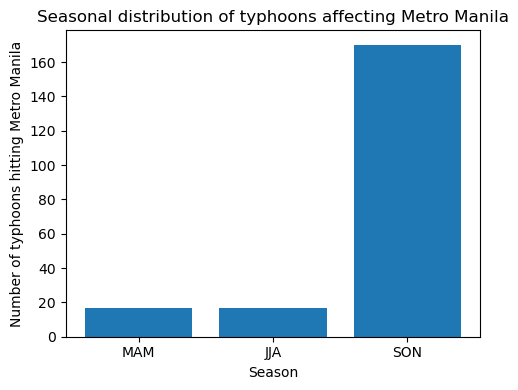

In [71]:
import matplotlib.pyplot as plt

# Ensure seasons are in a nice order
season_order = ["DJF", "MAM", "JJA", "SON"]

season_counts = (
    df["season"]
    .value_counts()
    .reindex(season_order)
)

plt.figure(figsize=(5, 4))
plt.bar(season_counts.index, season_counts.values)
plt.xlabel("Season")
plt.ylabel("Number of typhoons hitting Metro Manila")
plt.title("Seasonal distribution of typhoons affecting Metro Manila")
plt.tight_layout()
plt.show()

In [72]:
import pandas as pd

season_order = ["DJF", "MAM", "JJA", "SON"]

# Keep only rows with a valid season
tmp = df.loc[df["season"].notna(), ["season", "typhoon"]].drop_duplicates()

# Group into lists per season (only existing seasons)
storms_by_season = (
    tmp.groupby("season")["typhoon"]
       .apply(list)
       .to_dict()
)

# Pretty print in fixed season order
for season in season_order:
    storms = storms_by_season.get(season, [])  # [] if no storms for that season
    print(f"\n{season} ({len(storms)} typhoons):")
    if storms:
        print(", ".join(sorted(storms)))
    else:
        print("None")



DJF (0 typhoons):
None

MAM (1 typhoons):
Aghon

JJA (1 typhoons):
Carina

SON (10 typhoons):
Enteng, Jenny, Jolina, Karding, Kiko, Kristine, Paeng, Rolly, Ulysses, Uwan


In [73]:
season_typhoon_table = (
    pd.Series(storms_by_season, name="typhoon_list")   # dict -> Series
      .rename_axis("season")                          # index name
      .reset_index()                                  # to DataFrame
)

season_typhoon_table["n_typhoons"] = season_typhoon_table["typhoon_list"].apply(len)
season_typhoon_table


,season,typhoon_list,n_typhoons
0,JJA,[Carina],1
1,MAM,[Aghon],1
2,SON,"[Rolly, Ulysses, Jolina, Karding, Paeng, Jenny...",10


In [74]:
print("Target distribution:")
print(df[TARGET_COL].value_counts(dropna=False))
print("\nTarget proportions:")
print(df[TARGET_COL].value_counts(normalize=True))

Target distribution:
impact_severity_3band
Medium    95
Low       61
High      48
Name: count, dtype: int64

Target proportions:
impact_severity_3band
Medium    0.465686
Low       0.299020
High      0.235294
Name: proportion, dtype: float64


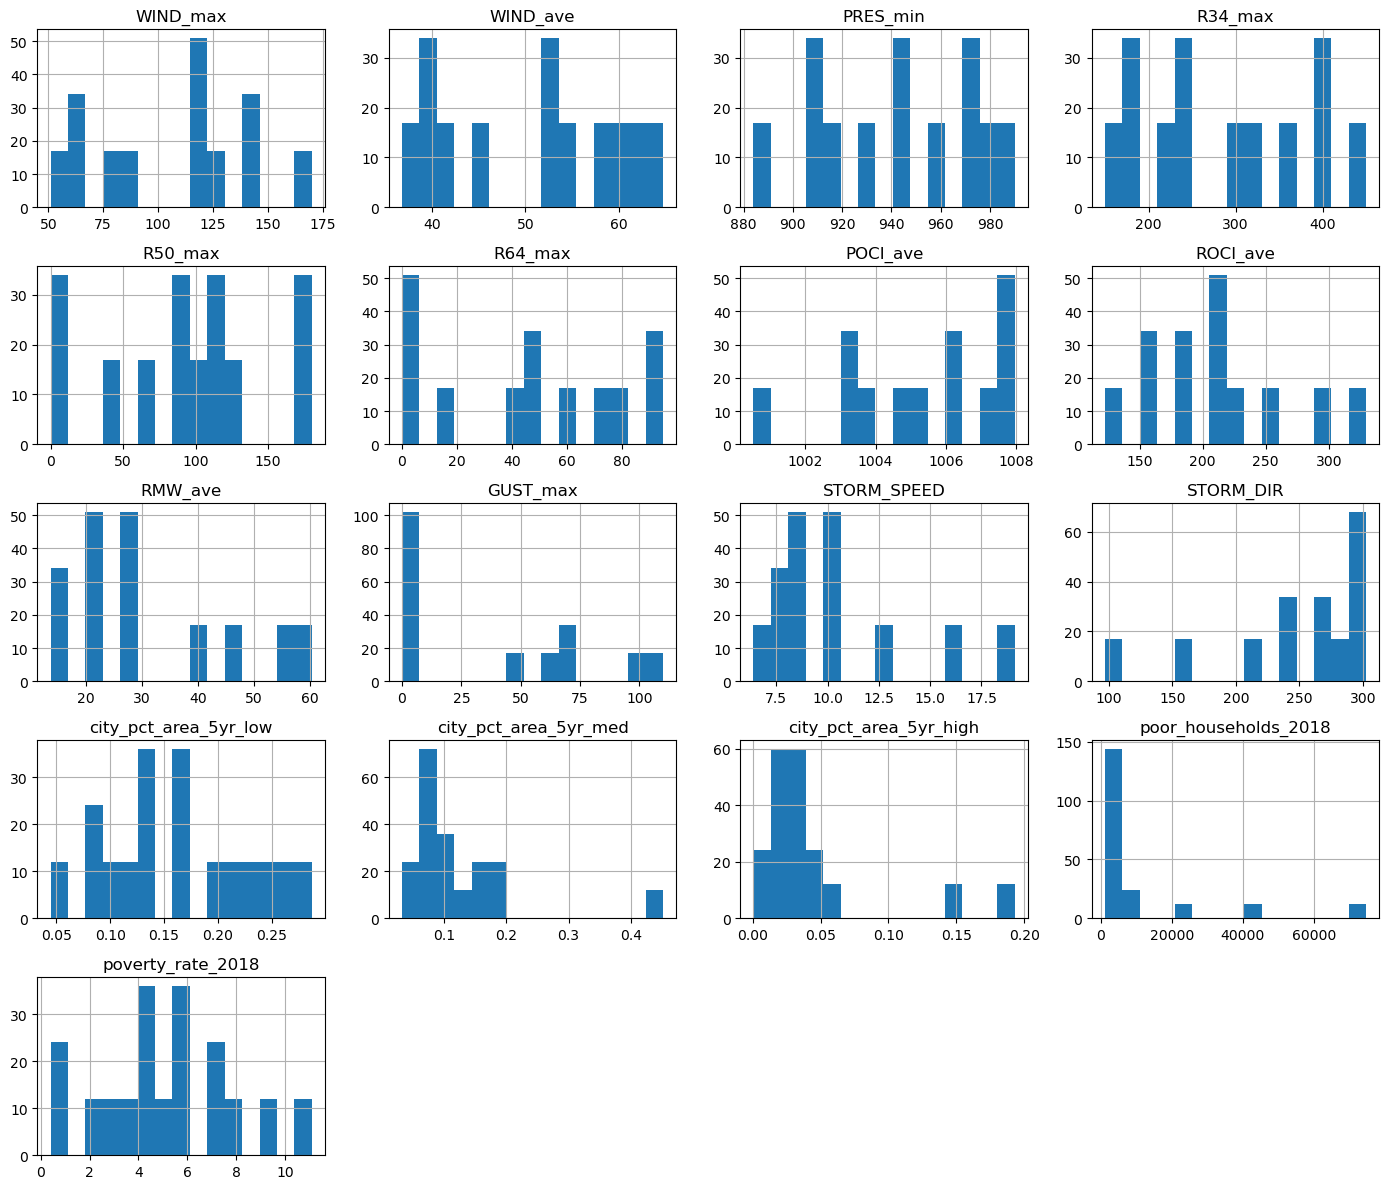

In [75]:
# Define numeric & categorical feature lists

# IBTrACS hazard columns (event-level)
ib_numeric = [
    "WIND_max", "WIND_ave", "PRES_min",
    "R34_max", "R50_max", "R64_max",
    "POCI_ave", "ROCI_ave", "RMW_ave",
    "GUST_max",
    "STORM_SPEED", "STORM_DIR"
]

# Flood hazard v1
flood_numeric = [c for c in flood_cols if c in df.columns]

# Poverty
poverty_numeric = ["poor_households_2018", "poverty_rate_2018"]

NUMERIC_FEATURES = ib_numeric + flood_numeric + poverty_numeric

for c in NUMERIC_FEATURES:
    if c not in df.columns:
        print(f"WARNING: numeric feature {c} not found in df; adjust NUMERIC_FEATURES.")

NUMERIC_FEATURES = [c for c in NUMERIC_FEATURES if c in df.columns]

df[NUMERIC_FEATURES].describe().T

# Histograms for numeric features
df[NUMERIC_FEATURES].hist(bins=15, figsize=(14, 12))
plt.tight_layout()
plt.show()


## 9. Handle Nulls

We will:
- Inspect null ratios for numeric features
- Drop extremely sparse features

In [76]:
null_ratio_num = df[NUMERIC_FEATURES].isna().mean().sort_values(ascending=False)
null_ratio_num

WIND_max                  0.0
WIND_ave                  0.0
PRES_min                  0.0
R34_max                   0.0
R50_max                   0.0
R64_max                   0.0
POCI_ave                  0.0
ROCI_ave                  0.0
RMW_ave                   0.0
GUST_max                  0.0
STORM_SPEED               0.0
STORM_DIR                 0.0
city_pct_area_5yr_low     0.0
city_pct_area_5yr_med     0.0
city_pct_area_5yr_high    0.0
poor_households_2018      0.0
poverty_rate_2018         0.0
dtype: float64

In [77]:
# Drop numeric features with > 70% missing, as an example threshold
THRESH = 0.7
sparse_cols = null_ratio_num[null_ratio_num > THRESH].index.tolist()
print("Dropping very sparse numeric features:", sparse_cols)

NUMERIC_FEATURES = [c for c in NUMERIC_FEATURES if c not in sparse_cols]

# Re-check
NUMERIC_FEATURES


Dropping very sparse numeric features: []


['WIND_max',
 'WIND_ave',
 'PRES_min',
 'R34_max',
 'R50_max',
 'R64_max',
 'POCI_ave',
 'ROCI_ave',
 'RMW_ave',
 'GUST_max',
 'STORM_SPEED',
 'STORM_DIR',
 'city_pct_area_5yr_low',
 'city_pct_area_5yr_med',
 'city_pct_area_5yr_high',
 'poor_households_2018',
 'poverty_rate_2018']

## 10. Multicollinearity

- Compute correlation matrix
- Identify highly correlated pairs

In [78]:
df.head()

,city_std,year,typhoon,typhoon_intl,combined_effect,combined_with,impact_severity_3band,SID,NAME,WIND_max,WIND_ave,PRES_min,R34_max,R50_max,R64_max,POCI_ave,ROCI_ave,RMW_ave,GUST_max,STORM_SPEED,STORM_DIR,storm_cluster,season,NATURE_peak,has_RI,first_RI_window_index,city_pct_area_5yr_low,city_pct_area_5yr_med,city_pct_area_5yr_high,poor_households_2018,poverty_rate_2018
0,Caloocan,2020,Rolly,goni,False,NaN,Low,2020299N11144,goni,170,52.495189,884,210,90,50,1007.952941,151.023529,26.56701,0,8.381443,272.319588,4.0,SON,TS,True,3.0,0.088791,0.061913,0.027458,74633,7.8
1,Las Piñas,2020,Rolly,goni,False,NaN,Low,2020299N11144,goni,170,52.495189,884,210,90,50,1007.952941,151.023529,26.56701,0,8.381443,272.319588,4.0,SON,TS,True,3.0,0.134296,0.112040,0.025844,4526,4.0
2,Makati,2020,Rolly,goni,False,NaN,Low,2020299N11144,goni,170,52.495189,884,210,90,50,1007.952941,151.023529,26.56701,0,8.381443,272.319588,4.0,SON,TS,True,3.0,0.194099,0.073259,0.026744,2288,0.9
3,Malabon,2020,Rolly,goni,False,NaN,Low,2020299N11144,goni,170,52.495189,884,210,90,50,1007.952941,151.023529,26.56701,0,8.381443,272.319588,4.0,SON,TS,True,3.0,0.251257,0.197348,0.035263,5781,9.0
4,Mandaluyong,2020,Rolly,goni,False,NaN,Low,2020299N11144,goni,170,52.495189,884,210,90,50,1007.952941,151.023529,26.56701,0,8.381443,272.319588,4.0,SON,TS,True,3.0,0.127377,0.083926,0.023636,2273,6.9


In [79]:
df.columns

Index(['city_std', 'year', 'typhoon', 'typhoon_intl', 'combined_effect', 'combined_with', 'impact_severity_3band', 'SID', 'NAME', 'WIND_max', 'WIND_ave', 'PRES_min', 'R34_max', 'R50_max', 'R64_max',
       'POCI_ave', 'ROCI_ave', 'RMW_ave', 'GUST_max', 'STORM_SPEED', 'STORM_DIR', 'storm_cluster', 'season', 'NATURE_peak', 'has_RI', 'first_RI_window_index', 'city_pct_area_5yr_low',
       'city_pct_area_5yr_med', 'city_pct_area_5yr_high', 'poor_households_2018', 'poverty_rate_2018'],
      dtype='object')

In [80]:
keep_cols = [
    'city_std', 'year', 'season', 'typhoon',
    'combined_effect', 
    'combined_with', 
    'SID', 'NAME', 'WIND_max', 'WIND_ave', 'PRES_min', 'R34_max', 
    'R50_max', 'R64_max', 'POCI_ave', 'ROCI_ave',
    'RMW_ave', 'GUST_max', 'STORM_SPEED', 'STORM_DIR', 
    'storm_cluster', 'NATURE_peak', 'has_RI', 'first_RI_window_index', 'city_pct_area_5yr_low', 
    'city_pct_area_5yr_med', 'city_pct_area_5yr_high', 'poor_households_2018',
    'poverty_rate_2018', 'impact_severity_3band'
]

df_model = df[keep_cols].copy()

# Drop rows with missing target (optional, but usually what you want for modeling)
TARGET_COL = "impact_severity_3band"
df_model = df_model.dropna(subset=[TARGET_COL])

df_model.head()


,city_std,year,season,typhoon,combined_effect,combined_with,SID,NAME,WIND_max,WIND_ave,PRES_min,R34_max,R50_max,R64_max,POCI_ave,ROCI_ave,RMW_ave,GUST_max,STORM_SPEED,STORM_DIR,storm_cluster,NATURE_peak,has_RI,first_RI_window_index,city_pct_area_5yr_low,city_pct_area_5yr_med,city_pct_area_5yr_high,poor_households_2018,poverty_rate_2018,impact_severity_3band
0,Caloocan,2020,SON,Rolly,False,NaN,2020299N11144,goni,170,52.495189,884,210,90,50,1007.952941,151.023529,26.56701,0,8.381443,272.319588,4.0,TS,True,3.0,0.088791,0.061913,0.027458,74633,7.8,Low
1,Las Piñas,2020,SON,Rolly,False,NaN,2020299N11144,goni,170,52.495189,884,210,90,50,1007.952941,151.023529,26.56701,0,8.381443,272.319588,4.0,TS,True,3.0,0.134296,0.112040,0.025844,4526,4.0,Low
2,Makati,2020,SON,Rolly,False,NaN,2020299N11144,goni,170,52.495189,884,210,90,50,1007.952941,151.023529,26.56701,0,8.381443,272.319588,4.0,TS,True,3.0,0.194099,0.073259,0.026744,2288,0.9,Low
3,Malabon,2020,SON,Rolly,False,NaN,2020299N11144,goni,170,52.495189,884,210,90,50,1007.952941,151.023529,26.56701,0,8.381443,272.319588,4.0,TS,True,3.0,0.251257,0.197348,0.035263,5781,9.0,Low
4,Mandaluyong,2020,SON,Rolly,False,NaN,2020299N11144,goni,170,52.495189,884,210,90,50,1007.952941,151.023529,26.56701,0,8.381443,272.319588,4.0,TS,True,3.0,0.127377,0.083926,0.023636,2273,6.9,Low


In [81]:
feature_cols = [c for c in keep_cols if c != TARGET_COL]

In [82]:
df[TARGET_COL] = df[TARGET_COL].replace({"Low":0, "Medium":1, "High":2})

C:\Users\ailene.nunez\AppData\Local\Temp\ipykernel_24116\1793720244.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[TARGET_COL] = df[TARGET_COL].replace({"Low":0, "Medium":1, "High":2})


In [83]:
categorical_cols = [
    'combined_with', 
    'storm_cluster', 
    'NATURE_peak',
    'season']

# Only keep those actually present in feature_cols
categorical_cols = [c for c in categorical_cols if c in feature_cols]

numeric_cols = [c for c in feature_cols if c not in categorical_cols]

print("Categorical:", categorical_cols)
print("Numeric:", numeric_cols)


Categorical: ['combined_with', 'storm_cluster', 'NATURE_peak', 'season']
Numeric: ['city_std', 'year', 'typhoon', 'combined_effect', 'SID', 'NAME', 'WIND_max', 'WIND_ave', 'PRES_min', 'R34_max', 'R50_max', 'R64_max', 'POCI_ave', 'ROCI_ave', 'RMW_ave', 'GUST_max', 'STORM_SPEED', 'STORM_DIR', 'has_RI', 'first_RI_window_index', 'city_pct_area_5yr_low', 'city_pct_area_5yr_med', 'city_pct_area_5yr_high', 'poor_households_2018', 'poverty_rate_2018']


In [84]:
# Numeric part
X_num = df[numeric_cols].copy()

# Categorical part → one-hot
X_cat = pd.get_dummies(
    df[categorical_cols],
    drop_first=True  # avoid dummy trap; you can set to False if you prefer
)

# Combine
X_encoded = pd.concat([X_num.reset_index(drop=True),
                       X_cat.reset_index(drop=True)], axis=1)

# Keep target as-is
y = df[TARGET_COL].copy()

# Final modeling table with encoded features + target
df_encoded = pd.concat([X_encoded, y.reset_index(drop=True)], axis=1)

print("Encoded feature shape:", X_encoded.shape)
print("Final modeling table shape:", df_encoded.shape)
df_encoded.head()


Encoded feature shape: (204, 30)
Final modeling table shape: (204, 31)


,city_std,year,typhoon,combined_effect,SID,NAME,WIND_max,WIND_ave,PRES_min,R34_max,R50_max,R64_max,POCI_ave,ROCI_ave,RMW_ave,GUST_max,STORM_SPEED,STORM_DIR,has_RI,first_RI_window_index,city_pct_area_5yr_low,city_pct_area_5yr_med,city_pct_area_5yr_high,poor_households_2018,poverty_rate_2018,storm_cluster,combined_with_SW Moonsoon,NATURE_peak_TS,season_MAM,season_SON,impact_severity_3band
0,Caloocan,2020,Rolly,False,2020299N11144,goni,170,52.495189,884,210,90,50,1007.952941,151.023529,26.56701,0,8.381443,272.319588,True,3.0,0.088791,0.061913,0.027458,74633,7.8,4.0,False,True,False,True,0
1,Las Piñas,2020,Rolly,False,2020299N11144,goni,170,52.495189,884,210,90,50,1007.952941,151.023529,26.56701,0,8.381443,272.319588,True,3.0,0.134296,0.112040,0.025844,4526,4.0,4.0,False,True,False,True,0
2,Makati,2020,Rolly,False,2020299N11144,goni,170,52.495189,884,210,90,50,1007.952941,151.023529,26.56701,0,8.381443,272.319588,True,3.0,0.194099,0.073259,0.026744,2288,0.9,4.0,False,True,False,True,0
3,Malabon,2020,Rolly,False,2020299N11144,goni,170,52.495189,884,210,90,50,1007.952941,151.023529,26.56701,0,8.381443,272.319588,True,3.0,0.251257,0.197348,0.035263,5781,9.0,4.0,False,True,False,True,0
4,Mandaluyong,2020,Rolly,False,2020299N11144,goni,170,52.495189,884,210,90,50,1007.952941,151.023529,26.56701,0,8.381443,272.319588,True,3.0,0.127377,0.083926,0.023636,2273,6.9,4.0,False,True,False,True,0


In [85]:
df_encoded.columns

Index(['city_std', 'year', 'typhoon', 'combined_effect', 'SID', 'NAME', 'WIND_max', 'WIND_ave', 'PRES_min', 'R34_max', 'R50_max', 'R64_max', 'POCI_ave', 'ROCI_ave', 'RMW_ave', 'GUST_max',
       'STORM_SPEED', 'STORM_DIR', 'has_RI', 'first_RI_window_index', 'city_pct_area_5yr_low', 'city_pct_area_5yr_med', 'city_pct_area_5yr_high', 'poor_households_2018', 'poverty_rate_2018',
       'storm_cluster', 'combined_with_SW Moonsoon', 'NATURE_peak_TS', 'season_MAM', 'season_SON', 'impact_severity_3band'],
      dtype='object')

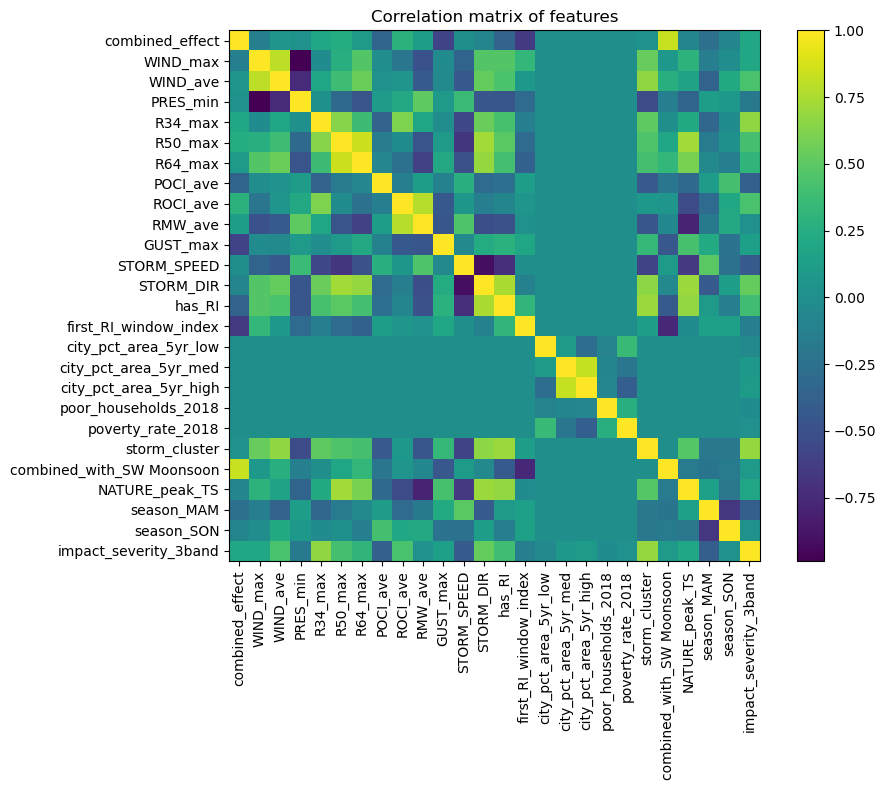

In [86]:
to_corr = ['combined_effect', 
           'WIND_max', 
           'WIND_ave', 
           'PRES_min', 
           'R34_max', 
           'R50_max', 
           'R64_max', 
           'POCI_ave', 
           'ROCI_ave', 
           'RMW_ave', 
           'GUST_max',
           'STORM_SPEED', 
           'STORM_DIR', 
           'has_RI', 
           'first_RI_window_index', 
           'city_pct_area_5yr_low', 
           'city_pct_area_5yr_med', 
           'city_pct_area_5yr_high', 
           'poor_households_2018', 
           'poverty_rate_2018',
           'storm_cluster', 
           'combined_with_SW Moonsoon', 
           'NATURE_peak_TS', 
           'season_MAM', 
           'season_SON', 
           'impact_severity_3band']
corr_mat = df_encoded[to_corr].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_mat, interpolation="nearest")
plt.xticks(range(len(to_corr)), to_corr, rotation=90)
plt.yticks(range(len(to_corr)), to_corr)
plt.colorbar()
plt.title("Correlation matrix of features")
plt.tight_layout()
plt.show()

In [87]:
# List pairs with |corr| > 0.9 for inspection
high_corr_pairs = []
for i in range(len(to_corr)):
    for j in range(i + 1, len(to_corr)):
        corr_val = corr_mat.iloc[i, j]
        if abs(corr_val) > 0.9:
            high_corr_pairs.append((to_corr[i], to_corr[j], corr_val))

high_corr_pairs

[('WIND_max', 'PRES_min', np.float64(-0.9866755397861886)),
 ('STORM_SPEED', 'STORM_DIR', np.float64(-0.9091960750859381))]

In [88]:
to_drop_for_corr = ['PRES_min', 'STORM_DIR']

In [89]:
to_corr = [c for c in to_corr if c not in to_drop_for_corr]
to_corr

['combined_effect',
 'WIND_max',
 'WIND_ave',
 'R34_max',
 'R50_max',
 'R64_max',
 'POCI_ave',
 'ROCI_ave',
 'RMW_ave',
 'GUST_max',
 'STORM_SPEED',
 'has_RI',
 'first_RI_window_index',
 'city_pct_area_5yr_low',
 'city_pct_area_5yr_med',
 'city_pct_area_5yr_high',
 'poor_households_2018',
 'poverty_rate_2018',
 'storm_cluster',
 'combined_with_SW Moonsoon',
 'NATURE_peak_TS',
 'season_MAM',
 'season_SON',
 'impact_severity_3band']

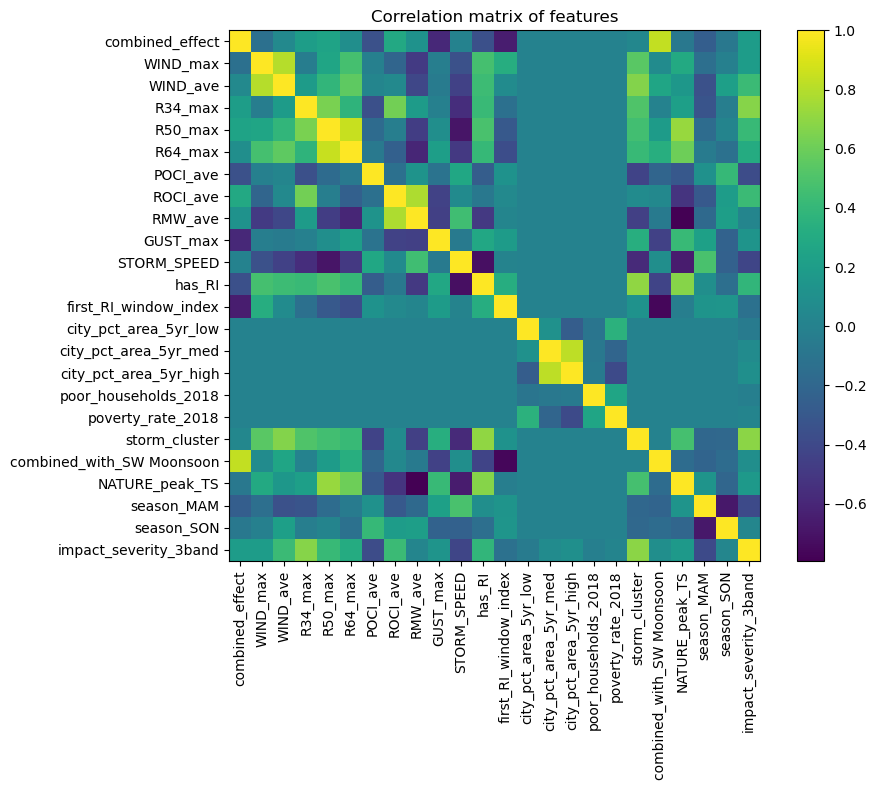

In [90]:
corr_mat = df_encoded[to_corr].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_mat, interpolation="nearest")
plt.xticks(range(len(to_corr)), to_corr, rotation=90)
plt.yticks(range(len(to_corr)), to_corr)
plt.colorbar()
plt.title("Correlation matrix of features")
plt.tight_layout()
plt.show()

In [91]:
# List pairs with |corr| > 0.9 for inspection
high_corr_pairs = []
for i in range(len(to_corr)):
    for j in range(i + 1, len(to_corr)):
        corr_val = corr_mat.iloc[i, j]
        if abs(corr_val) > 0.9:
            high_corr_pairs.append((to_corr[i], to_corr[j], corr_val))

high_corr_pairs

[]

## 11. Modeling

Models:
- AdaBoostClassifier
- Perceptron
- SVM (RBF)
- Naive Bayes

Features:
- Numeric: IBTrACS hazard, flood hazard, poverty
- Categorical: city_std, NATURE, storm_cluster, year, typhoon_intl

In [92]:
df_encoded[NUMERIC_FEATURES].fillna(0, inplace=True)

C:\Users\ailene.nunez\AppData\Local\Temp\ipykernel_24116\2493339544.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_encoded[NUMERIC_FEATURES].fillna(0, inplace=True)


### 11.1 Splitting Train and Test Sets

In [93]:
feature_cols = [
    c for c in df_model.columns
    if (c in to_corr) and (c != TARGET_COL)
]

# --- Config ---
TARGET_COL = "impact_severity_3band"
GROUP_COL = "typhoon"          # or "storm_id" if you have one
FEATURE_COLS = feature_cols    # reuse your existing list

df = df_encoded.copy()

# Train = <= 2024, Test = 2025
df_train = df[df["year"] <= 2024].copy()
df_test  = df[df["year"] == 2025].copy()

X_train = df_train[FEATURE_COLS].values
y_train = df_train[TARGET_COL].values
groups_train = df_train[GROUP_COL].values

X_test  = df_test[FEATURE_COLS].values
y_test  = df_test[TARGET_COL].values

# --- 2a. Inspect class distribution ---
print("Overall class distribution (train only):")
counts = pd.Series(y_train).value_counts().sort_index()
print(counts)
print((counts / counts.sum() * 100).round(1).astype(str) + "%")

print("\nClass distribution by year (train):")
print(
    df_train.groupby("year")[TARGET_COL]
            .value_counts(normalize=True)
            .rename("share")
            .mul(100).round(1)
            .unstack(fill_value=0)
)

# --- 2b. Compute class weights for imbalance ---
classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)
class_weight_dict = dict(zip(classes, class_weights))

print("\nClass weights (for SVM & Perceptron):")
print(class_weight_dict)


Overall class distribution (train only):
0    44
1    83
2    43
Name: count, dtype: int64
0    25.9%
1    48.8%
2    25.3%
Name: count, dtype: object

Class distribution by year (train):
impact_severity_3band     0     1     2
year                                   
2020                   41.2  20.6  38.2
2021                   76.5  23.5   0.0
2022                    0.0  88.2  11.8
2023                    0.0  94.1   5.9
2024                   25.0  38.2  36.8

Class weights (for SVM & Perceptron):
{np.int64(0): np.float64(1.2878787878787878), np.int64(1): np.float64(0.6827309236947792), np.int64(2): np.float64(1.317829457364341)}


### 11.3 Scaling

In [94]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

### 11.4 Perceptron

In [95]:
perc_clf = Perceptron(
    max_iter=1000,
    eta0=0.01,
    early_stopping=True,
    validation_fraction=0.1,
    class_weight="balanced",
    random_state=42
)

perc_clf.fit(X_train_scaled, y_train)
y_pred_perc = perc_clf.predict(X_test_scaled)

In [96]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

def evaluate_model(model, X, y_true, model_name="Model", class_names=None):
    """
    Fit-independent evaluation helper.
    
    Parameters
    ----------
    model : fitted sklearn-like estimator
        Must implement .predict().
    X : array-like
        Features to predict on (e.g., X_test or X_test_scaled).
    y_true : array-like
        True labels.
    model_name : str, optional
        Name to show in prints/plot titles.
    class_names : list or array, optional
        Labels to display on confusion matrix axes. If None, uses np.unique(y_true).
    """
    # Prediction
    y_pred = model.predict(X)
    
    # Basic metrics
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro")
    
    print(f"\n=== {model_name} ===")
    print(f"Accuracy    : {acc:.3f}")
    print(f"Macro F1    : {f1_macro:.3f}")
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, digits=3))
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    if class_names is None:
        class_names = np.unique(y_true)
    
    fig, ax = plt.subplots(figsize=(4, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"Confusion matrix – {model_name}")
    plt.tight_layout()
    plt.show()



=== Perceptron ===
Accuracy    : 0.529
Macro F1    : 0.417

Classification report:
              precision    recall  f1-score   support

           0      1.000     0.765     0.867        17
           1      0.000     0.000     0.000        12
           2      0.238     1.000     0.385         5

    accuracy                          0.529        34
   macro avg      0.413     0.588     0.417        34
weighted avg      0.535     0.529     0.490        34



c:\Users\ailene.nunez\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ailene.nunez\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ailene.nunez\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


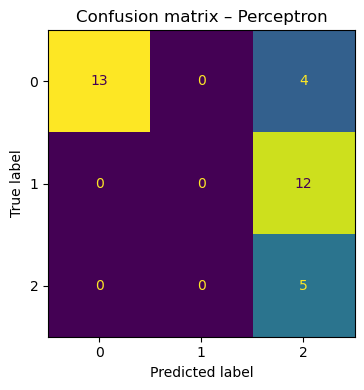

In [97]:
evaluate_model(perc_clf, X_test_scaled, y_test, model_name="Perceptron", class_names=[0, 1, 2])

### 11.4 AdaBoost

In [98]:
perc_weak = Perceptron(
    max_iter=1000,
    eta0=0.01,
    early_stopping=False,      
    class_weight="balanced",  
    random_state=42
)

ada_perc_clf = AdaBoostClassifier(
    estimator=perc_weak,
    n_estimators=50,        
    learning_rate=0.5,
    algorithm="SAMME",      
    random_state=42
)

ada_perc_clf.fit(X_train_scaled, y_train)
y_pred_ada_perc = ada_perc_clf.predict(X_test_scaled)

c:\Users\ailene.nunez\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


c:\Users\ailene.nunez\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



=== AdaBoost+Perceptron ===
Accuracy    : 0.324
Macro F1    : 0.275

Classification report:
              precision    recall  f1-score   support

           0      1.000     0.353     0.522        17
           1      0.000     0.000     0.000        12
           2      0.179     1.000     0.303         5

    accuracy                          0.324        34
   macro avg      0.393     0.451     0.275        34
weighted avg      0.526     0.324     0.305        34



c:\Users\ailene.nunez\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ailene.nunez\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


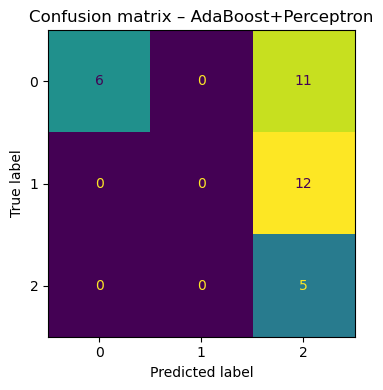

In [99]:
evaluate_model(ada_perc_clf, X_test_scaled, y_test, model_name="AdaBoost+Perceptron", class_names=[0, 1, 2])

### 11.5 SVM (RBF)

In [100]:
svm_clf = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    class_weight="balanced",
    probability=True,
    random_state=42
)

svm_clf.fit(X_train_scaled, y_train)
y_pred_svm = svm_clf.predict(X_test_scaled)



=== SVM ===
Accuracy    : 0.382
Macro F1    : 0.376

Classification report:
              precision    recall  f1-score   support

           0      0.000     0.000     0.000        17
           1      0.333     0.750     0.462        12
           2      0.571     0.800     0.667         5

    accuracy                          0.382        34
   macro avg      0.302     0.517     0.376        34
weighted avg      0.202     0.382     0.261        34



c:\Users\ailene.nunez\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ailene.nunez\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ailene.nunez\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


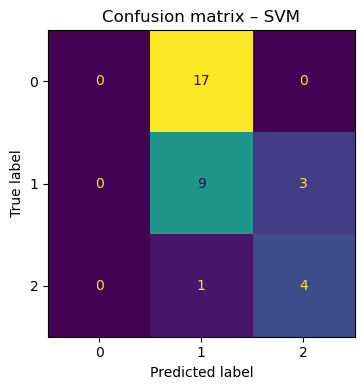

In [101]:
evaluate_model(svm_clf, X_test_scaled, y_test, model_name="SVM", class_names=[0, 1, 2])

### 11.6 Naive Bayes

In [102]:
nb_clf = GaussianNB()

nb_clf.fit(X_train_scaled, y_train)
y_pred_nb = nb_clf.predict(X_test_scaled)



=== Naive-Bayes ===
Accuracy    : 0.382
Macro F1    : 0.289

Classification report:
              precision    recall  f1-score   support

           0      0.000     0.000     0.000        17
           1      0.364     1.000     0.533        12
           2      1.000     0.200     0.333         5

    accuracy                          0.382        34
   macro avg      0.455     0.400     0.289        34
weighted avg      0.275     0.382     0.237        34



c:\Users\ailene.nunez\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ailene.nunez\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ailene.nunez\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


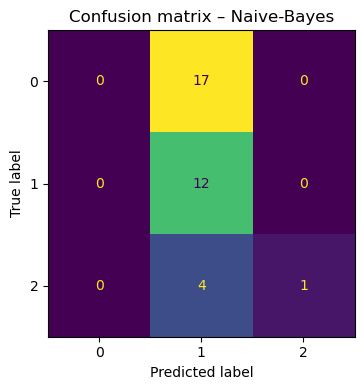

In [103]:
evaluate_model(nb_clf, X_test_scaled, y_test, model_name="Naive-Bayes", class_names=[0, 1, 2])

### 11.7 XGBoost

In [104]:
sample_weight_train = np.array([class_weight_dict[int(y)] for y in y_train])

In [105]:
xgb_clf = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    learning_rate=0.1,
    n_estimators=200,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_clf.fit(
    X_train_scaled,
    y_train,
    sample_weight=sample_weight_train
)

y_pred_xgb = xgb_clf.predict(X_test_scaled)



=== XGB ===
Accuracy    : 0.853
Macro F1    : 0.710

Classification report:
              precision    recall  f1-score   support

           0      1.000     0.941     0.970        17
           1      0.706     1.000     0.828        12
           2      1.000     0.200     0.333         5

    accuracy                          0.853        34
   macro avg      0.902     0.714     0.710        34
weighted avg      0.896     0.853     0.826        34



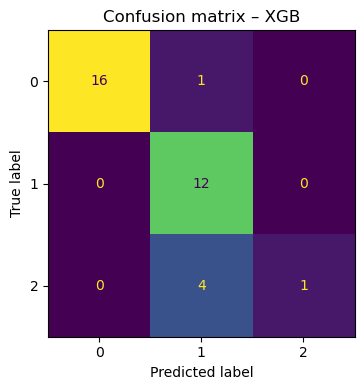

In [106]:
evaluate_model(xgb_clf, X_test_scaled, y_test, model_name="XGB", class_names=[0, 1, 2])

### 11.8 Cross-validation comparison (macro F1)

In [107]:
# groups = storm identifiers for each row in X_train_scaled / y_train
groups_train = df_train["typhoon"].values

# Make sure we don't ask for more folds than storms
unique_storms = np.unique(groups_train)
n_splits = min(5, len(unique_storms))

cv = GroupKFold(n_splits=n_splits)

# Instantiate Naive Bayes
nb_clf = GaussianNB()

models = {
    "AdaBoost": ada_perc_clf,
    "Perceptron": perc_clf,
    "SVM": svm_clf,
    "NaiveBayes": nb_clf
}

for name, clf in models.items():
    scores = cross_val_score(
        clf,
        X_train_scaled,
        y_train,
        cv=cv,
        groups=groups_train,
        scoring="f1_macro",
        n_jobs=-1
    )
    print(f"{name}: mean F1_macro = {scores.mean():.3f} ± {scores.std():.3f}")

AdaBoost: mean F1_macro = 0.366 ± 0.091
Perceptron: mean F1_macro = 0.283 ± 0.100
SVM: mean F1_macro = 0.431 ± 0.063
NaiveBayes: mean F1_macro = 0.367 ± 0.154


In [108]:
f1_scores_xgb = []

for fold_idx, (tr_idx, val_idx) in enumerate(cv.split(X_train, y_train, groups_train), 1):
    X_tr, X_val = X_train[tr_idx], X_train[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]
    w_tr = sample_weight_train[tr_idx]

    xgb_fold = XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        learning_rate=0.1,
        n_estimators=200,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    xgb_fold.fit(X_tr, y_tr, sample_weight=w_tr)
    y_pred_val = xgb_fold.predict(X_val)

    f1 = f1_score(y_val, y_pred_val, average="macro")
    f1_scores_xgb.append(f1)
    print(f"XGBoost fold {fold_idx}: F1_macro = {f1:.3f}")

print(f"\nXGBoost: mean F1_macro = {np.mean(f1_scores_xgb):.3f} ± {np.std(f1_scores_xgb):.3f}")


XGBoost fold 1: F1_macro = 0.391
XGBoost fold 2: F1_macro = 0.554
XGBoost fold 3: F1_macro = 0.504
XGBoost fold 4: F1_macro = 0.454
XGBoost fold 5: F1_macro = 0.422

XGBoost: mean F1_macro = 0.465 ± 0.058


### 11.9 Tune XGB

In [109]:
FACTOR_LIST = [1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]   # λ

results = []

for FACTOR_HIGH in FACTOR_LIST:
    # per-sample weights: 0=1, 1=λ/2, 2=λ
    weights = np.ones_like(y_train, dtype=float)
    # weights[y_train == 1] = FACTOR_HIGH / 2.0
    weights[y_train == 2] = FACTOR_HIGH

    xgb_temp = XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        learning_rate=0.1,
        n_estimators=200,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    xgb_temp.fit(X_train_scaled, y_train, sample_weight=weights)
    y_pred = xgb_temp.predict(X_test_scaled)

    report = classification_report(y_test, y_pred, digits=3, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n=== λ={FACTOR_HIGH:.1f} (w0=1, w1={FACTOR_HIGH/2:.1f}, w2={FACTOR_HIGH:.1f}) ===")
    print("Class 2: P={:.3f}, R={:.3f}, F1={:.3f}".format(
        report["2"]["precision"],
        report["2"]["recall"],
        report["2"]["f1-score"],
    ))
    print("Confusion matrix:\n", cm)

    results.append({
        "lambda": FACTOR_HIGH,
        "prec_2": report["2"]["precision"],
        "recall_2": report["2"]["recall"],
        "f1_2": report["2"]["f1-score"],
        "macro_f1": report["macro avg"]["f1-score"],
    })

res_df = pd.DataFrame(results)
print("\nSummary:")
print(res_df)



=== λ=1.0 (w0=1, w1=0.5, w2=1.0) ===
Class 2: P=1.000, R=0.200, F1=0.333
Confusion matrix:
 [[15  2  0]
 [ 0 12  0]
 [ 0  4  1]]

=== λ=1.5 (w0=1, w1=0.8, w2=1.5) ===
Class 2: P=0.500, R=0.200, F1=0.286
Confusion matrix:
 [[15  2  0]
 [ 0 11  1]
 [ 0  4  1]]

=== λ=2.0 (w0=1, w1=1.0, w2=2.0) ===
Class 2: P=0.500, R=0.200, F1=0.286
Confusion matrix:
 [[16  1  0]
 [ 0 11  1]
 [ 0  4  1]]

=== λ=3.0 (w0=1, w1=1.5, w2=3.0) ===
Class 2: P=0.600, R=0.600, F1=0.600
Confusion matrix:
 [[16  1  0]
 [ 0 10  2]
 [ 0  2  3]]

=== λ=4.0 (w0=1, w1=2.0, w2=4.0) ===
Class 2: P=0.600, R=0.600, F1=0.600
Confusion matrix:
 [[15  2  0]
 [ 0 10  2]
 [ 0  2  3]]

=== λ=5.0 (w0=1, w1=2.5, w2=5.0) ===
Class 2: P=0.500, R=0.600, F1=0.545
Confusion matrix:
 [[14  2  1]
 [ 0 10  2]
 [ 0  2  3]]

=== λ=6.0 (w0=1, w1=3.0, w2=6.0) ===
Class 2: P=0.600, R=0.600, F1=0.600
Confusion matrix:
 [[15  2  0]
 [ 0 10  2]
 [ 0  2  3]]

=== λ=7.0 (w0=1, w1=3.5, w2=7.0) ===
Class 2: P=0.667, R=0.800, F1=0.727
Confusion matrix

In [124]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Recompute balanced class weights (using your current clean dataset)
classes = np.unique(y_train)
class_weights = compute_class_weight("balanced", classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

print("Balanced class weights:", class_weight_dict)

# Base sample weights from balanced scheme
sample_weight_train = np.array([class_weight_dict[int(y)] for y in y_train])

# Extra emphasis on class 2 (High). You can try 1.5, 2.0, 3.0, etc.
FACTOR_HIGH = 4
sample_weight_train_high = sample_weight_train.copy()
sample_weight_train_high[y_train == 2] *= FACTOR_HIGH 
sample_weight_train_high[y_train == 1] *= FACTOR_HIGH /2

Balanced class weights: {np.int64(0): np.float64(1.2878787878787878), np.int64(1): np.float64(0.6827309236947792), np.int64(2): np.float64(1.317829457364341)}



=== XGB ===
Accuracy    : 0.853
Macro F1    : 0.822

Classification report:
              precision    recall  f1-score   support

           0      1.000     0.882     0.938        17
           1      0.769     0.833     0.800        12
           2      0.667     0.800     0.727         5

    accuracy                          0.853        34
   macro avg      0.812     0.839     0.822        34
weighted avg      0.870     0.853     0.858        34



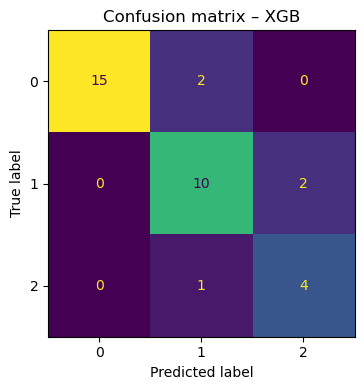

In [125]:
xgb_weighted = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    learning_rate=0.1,
    n_estimators=200,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_weighted.fit(
    X_train_scaled,
    y_train,
    sample_weight=sample_weight_train_high
)

y_pred_xgb = xgb_weighted.predict(X_test_scaled)
evaluate_model(xgb_weighted, X_test_scaled, y_test, model_name="XGB", class_names=[0, 1, 2])

### 11.10 Feature Importance

In [112]:
import shap
import numpy as np

shap.initjs() 

X_shap = X_train_scaled[:100]

In [113]:
explainer = shap.TreeExplainer(xgb_weighted)
shap_values = explainer.shap_values(X_shap)


In [114]:
# Your feature names, same order as columns used to build X_train_scaled
feature_names = feature_cols

# Extract SHAP for class 2 (High impact)
if isinstance(shap_values, list):
    shap_values_high = shap_values[2]              # array (n_samples, n_features)
    expected_value_high = explainer.expected_value[2]
else:
    shap_values_high = shap_values[:, :, 2]        # take slice for class 2
    expected_vals = explainer.expected_value
    # expected_value may be scalar or array per class
    if np.ndim(expected_vals) == 0:
        expected_value_high = expected_vals
    else:
        expected_value_high = expected_vals[2]


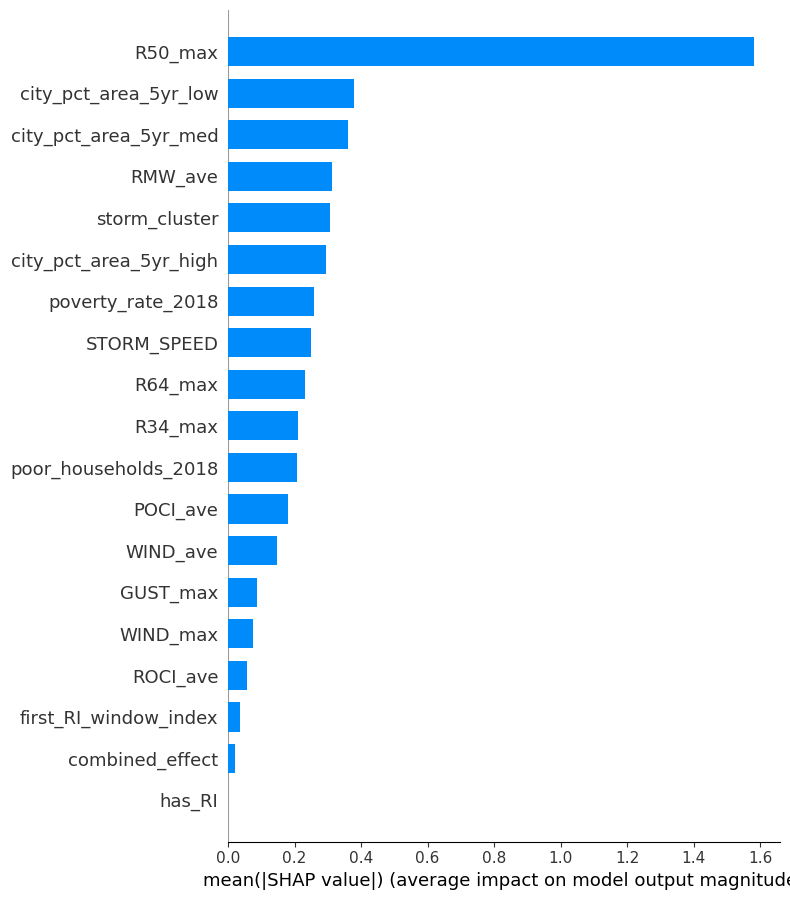

In [115]:
# Bar-type summary plot: which features matter most on average for class 2
shap.summary_plot(
    shap_values_high,
    X_shap,
    feature_names=feature_names,
    plot_type="bar",
    show=True
)

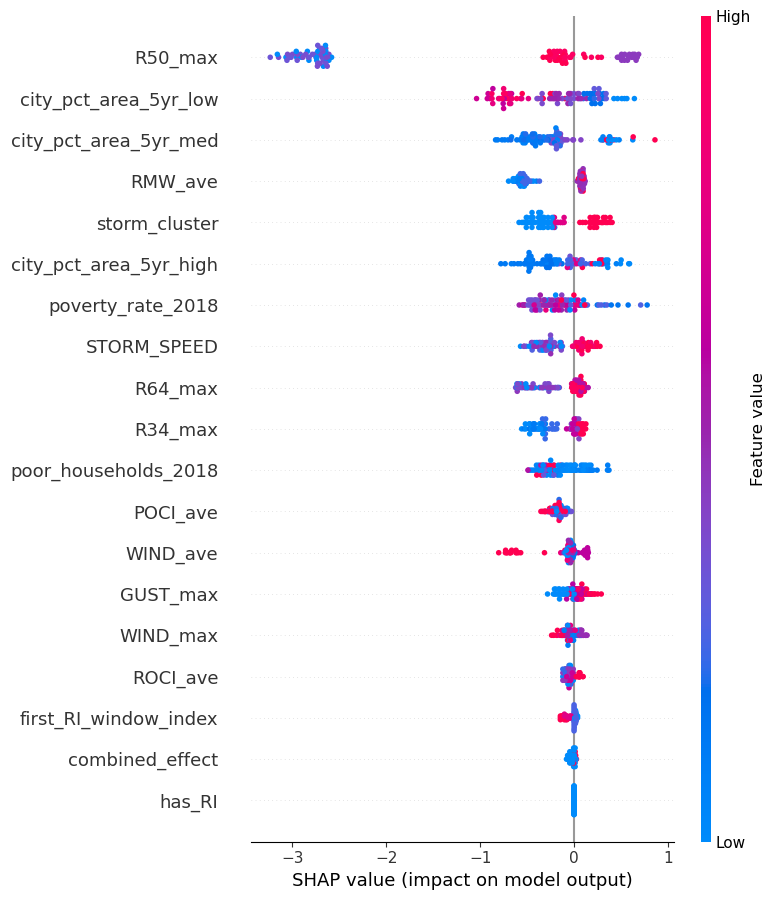

In [116]:
# Beeswarm summary: direction + magnitude
shap.summary_plot(
    shap_values_high,
    X_shap,
    feature_names=feature_names,
    show=True
)


In [117]:
i = 0  # index into X_shap / df_train row

shap.force_plot(
    expected_value_high,
    shap_values_high[i],
    X_shap[i, :],
    feature_names=feature_names
)